In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import seaborn as sns
from xgboost import XGBClassifier
from scipy.stats import kurtosis
from scipy.stats import skew

In [2]:
# Step 1: Load the datasets
df_class_0 = pd.read_csv("dataset/features_set_0_lbp.csv")
df_class_1 = pd.read_csv("dataset/features_set_1_lbp.csv")


# Step 2: Add class labels to each dataset
df_class_0['target'] = 0  # Label for class 0
df_class_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined = pd.concat([df_class_0, df_class_1], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined = df_combined.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows

In [3]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1121 entries, 0 to 1120
Columns: 216 entries, Unnamed: 0 to target
dtypes: float64(214), int64(1), object(1)
memory usage: 1.8+ MB


In [4]:
df_combined.fillna(0, inplace=True)

In [109]:
# Step 4: Separate features (X) and target (y)
X = df_combined.drop(columns=['target', 'Unnamed: 0'])  # Features
y = df_combined['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=500, random_state=142, max_depth=None)
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [110]:
# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.84

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       100
           1       0.85      0.86      0.86       125

    accuracy                           0.84       225
   macro avg       0.84      0.84      0.84       225
weighted avg       0.84      0.84      0.84       225

ROC-AUC Score: 0.90212


[[ 81  19]
 [ 17 108]]


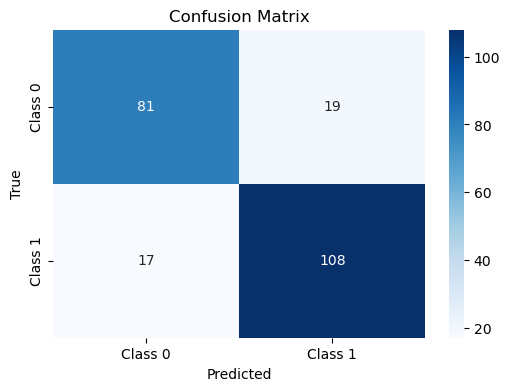

In [111]:
# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [112]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy: ", scores.mean())

Cross-Validation Accuracy:  0.7903531746031746


In [113]:
# Extract the sample IDs
sample_ids = df_combined["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined[df_combined['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(feature_values)
            summary[f'{feature}_max'] = np.max(feature_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_se'] = np.std(feature_values) / np.sqrt(len(feature_values))
            summary[f'{feature}_skew'] = skew(feature_values)
            summary[f'{feature}_kurtosis'] = kurtosis(feature_values)
          
        else:
            # Set default values for empty data
            summary[f'{feature}_mean'] = 0
            summary[f'{feature}_max'] = 0
            summary[f'{feature}_min'] = 0
            summary[f'{feature}_se'] = 0
            summary[f'{feature}_skew'] = 0
            summary[f'{feature}_kurtosis'] = 0

    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
print(summary_df.head())

                           Sample_ID  count_objects  area_mean  area_max  \
0   13693_idx5_x2351_y851_class0.png              1     62.425    2497.0   
1   12749_idx5_x2501_y851_class1.png             40      2.450      12.0   
2  10285_idx5_x1151_y1001_class1.png              6     46.425    1843.0   
3   12894_idx5_x601_y1851_class0.png              1     61.875    2475.0   
4  14155_idx5_x2401_y1351_class1.png              1     56.650    2266.0   

   area_min    area_se  area_skew  area_kurtosis  perimeter_mean  \
0    2497.0  61.639749   6.084870      35.025641        5.232843   
1       1.0   0.415256   2.147244       3.893536        1.469975   
2       1.0  45.486837   6.084751      35.024702       24.412515   
3    2475.0  61.096667   6.084870      35.025641        7.304163   
4    2266.0  55.937393   6.084870      35.025641       16.205687   

   perimeter_max  ...  major_axis_length_min  major_axis_length_se  \
0     209.313708  ...              57.754305              1.4256

In [114]:
# Drop morphological features from original_df
morphological_features = [col for col in df_combined.columns if col.startswith("morphological_")]
filtered_df = df_combined.drop(columns=morphological_features)

# Merge the summarized morphological stats
merged_df = filtered_df.merge(summary_df, left_index=True, right_index=True)

# Save merged dataframe
merged_df.to_csv("merged_features_histo_images.csv")

print("Merged DataFrame shape:", merged_df.shape)

Merged DataFrame shape: (1121, 48)


In [115]:
merged_df

,Unnamed: 0,GLCM_1_Contrast,GLCM_1_Correlation,GLCM_1_Energy,GLCM_1_Homogeneity,LBP_0,LBP_1,LBP_2,LBP_3,LBP_4,...,major_axis_length_min,major_axis_length_se,major_axis_length_skew,major_axis_length_kurtosis,minor_axis_length_mean,minor_axis_length_max,minor_axis_length_min,minor_axis_length_se,minor_axis_length_skew,minor_axis_length_kurtosis
0,13693_idx5_x2351_y851_class0.png,0.000582,496.944598,0.079509,455.711346,0.1392,0.1084,0.0520,0.0588,0.0824,...,57.754305,1.425695,6.084870,35.025641,1.442875,57.715015,57.715015,1.424725,6.084870,35.025641
1,12749_idx5_x2501_y851_class1.png,0.000522,564.790820,0.074852,407.858661,0.1248,0.1144,0.0656,0.0680,0.0752,...,2.000000,0.433580,1.625681,1.691122,0.411857,3.026469,0.837402,0.128501,2.033239,3.282035
2,10285_idx5_x1151_y1001_class1.png,0.000403,1213.747718,0.056157,1184.705794,0.1380,0.1192,0.0620,0.0556,0.0600,...,2.828427,1.445294,5.951726,33.936631,1.563789,57.975022,0.828427,1.429816,6.064188,34.859202
3,12894_idx5_x601_y1851_class0.png,0.000369,737.456472,0.059903,770.176774,0.1224,0.1132,0.0708,0.0656,0.0904,...,57.717396,1.424784,6.084870,35.025641,1.439769,57.590742,57.590742,1.421658,6.084870,35.025641
4,14155_idx5_x2401_y1351_class1.png,0.000704,1154.067940,0.084441,1530.003943,0.1220,0.0992,0.0576,0.1128,0.1028,...,58.287178,1.438849,6.084870,35.025641,1.424186,56.967456,56.967456,1.406271,6.084870,35.025641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1116,13693_idx5_x351_y851_class0.png,0.001071,259.421597,0.112710,348.104693,0.1408,0.1180,0.0564,0.0600,0.0624,...,57.868055,1.428503,6.084870,35.025641,1.429867,57.194671,57.194671,1.411880,6.084870,35.025641
1117,12749_idx5_x3001_y1401_class1.png,0.002085,1888.383322,0.122425,2393.146518,0.1124,0.0912,0.0724,0.1388,0.1176,...,3.098387,1.451468,5.982937,34.190497,1.417164,54.897708,1.788854,1.354766,6.074882,34.945008
1118,13462_idx5_x501_y1301_class1.png,0.000503,788.576335,0.065592,610.057172,0.1204,0.1312,0.0616,0.0652,0.0784,...,58.557488,1.445522,6.084870,35.025641,1.454138,58.165526,58.165526,1.435846,6.084870,35.025641
1119,12749_idx5_x1451_y251_class0.png,0.001082,1706.710793,0.110393,3755.234588,0.1104,0.0968,0.0652,0.1232,0.1120,...,2.000000,1.339470,4.632096,23.085239,1.852180,24.641946,0.828427,0.655952,4.320938,20.152294


In [159]:
# Step 4: Separate features (X) and target (y)
X = merged_df.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=None, class_weight="balanced")
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [160]:
# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.76      0.77       100
           1       0.81      0.83      0.82       125

    accuracy                           0.80       225
   macro avg       0.80      0.80      0.80       225
weighted avg       0.80      0.80      0.80       225

ROC-AUC Score: 0.86416


[[ 76  24]
 [ 21 104]]


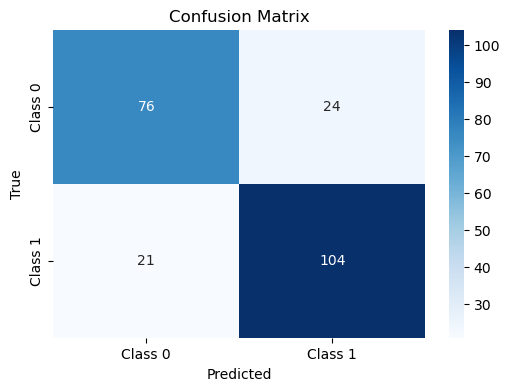

In [157]:
# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

                       Feature  Importance
15                   area_mean    0.055276
16                    area_max    0.053657
18                     area_se    0.052726
2                GLCM_1_Energy    0.045806
24                perimeter_se    0.043782
0              GLCM_1_Contrast    0.043563
22               perimeter_max    0.039102
8                        LBP_4    0.036059
17                    area_min    0.033385
36        major_axis_length_se    0.031004
21              perimeter_mean    0.030517
9                        LBP_5    0.028356
34       major_axis_length_max    0.026498
10                       LBP_6    0.026204
7                        LBP_3    0.025300
13                       LBP_9    0.024707
3           GLCM_1_Homogeneity    0.024602
23               perimeter_min    0.023847
39      minor_axis_length_mean    0.023197
1           GLCM_1_Correlation    0.022753
6                        LBP_2    0.021622
30             eccentricity_se    0.021547
4          

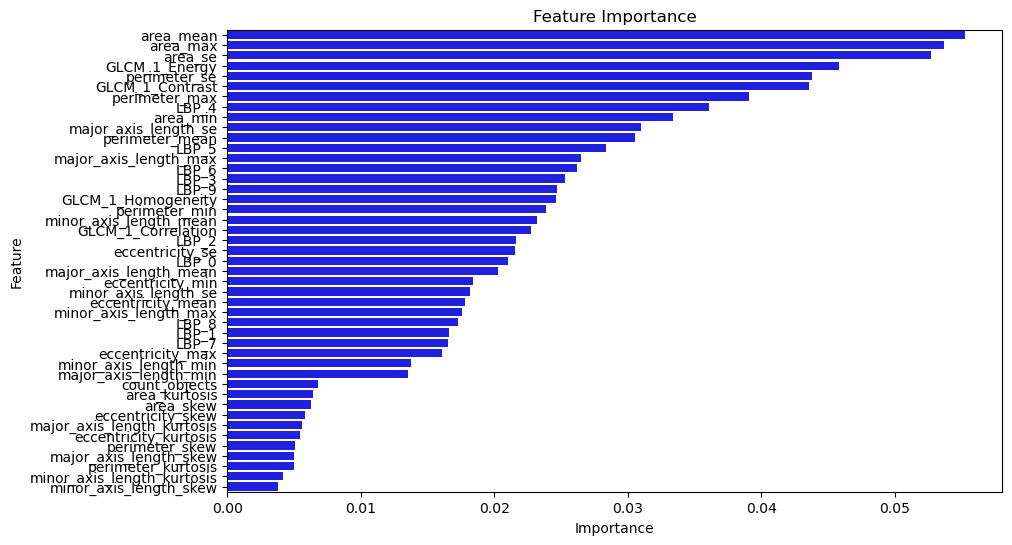

In [123]:
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### XGB_model:

In [76]:
# Step 4: Separate features (X) and target (y)
X = merged_df.drop(columns=['target', 'Unnamed: 0', 'Sample_ID'])  # Features
y = merged_df['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=142)
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [77]:
# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Fit the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]  # For ROC/AUC

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC AUC Score: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       100
           1       0.81      0.83      0.82       125

    accuracy                           0.80       225
   macro avg       0.79      0.79      0.79       225
weighted avg       0.80      0.80      0.80       225


Confusion Matrix:
[[ 75  25]
 [ 21 104]]

ROC AUC Score: 0.8798


In [78]:
# Feature Selection with SelectKBest (using mutual information classification score)
selector = SelectKBest(score_func=mutual_info_classif, k='all')  # You can change 'k' to select top k features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, max_depth=None)

# Fit the model
xgb_model.fit(X_train_selected, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test_selected)
y_pred_prob = xgb_model.predict_proba(X_test_selected)[:, 1]  # For ROC/AUC

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC AUC Score: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       100
           1       0.81      0.83      0.82       125

    accuracy                           0.80       225
   macro avg       0.79      0.79      0.79       225
weighted avg       0.80      0.80      0.80       225


Confusion Matrix:
[[ 75  25]
 [ 21 104]]

ROC AUC Score: 0.8798


In [79]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [3, 5, 7, None],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


# Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
                           param_grid=param_grid,
                           scoring='accuracy',  # Change to 'recall' or 'roc_auc' if desired
                           cv=5,
                           verbose=1,
                           n_jobs=-1)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Best parameters and model evaluation
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Evaluate the optimized model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nOptimized ROC AUC Score: {roc_auc:.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': None, 'n_estimators': 200, 'subsample': 0.8}

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       100
           1       0.84      0.85      0.84       125

    accuracy                           0.83       225
   macro avg       0.82      0.82      0.82       225
weighted avg       0.83      0.83      0.83       225


Confusion Matrix:
[[ 80  20]
 [ 19 106]]

Optimized ROC AUC Score: 0.8800


In [124]:
# Extract the sample IDs
sample_ids = df_combined["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined[df_combined['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined.columns if col.startswith('LBP_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
  
    
    # Compute statistics for each feature
    for feature in feature_columns:
        feature_values = feature_data.values.flatten()
        
   #     summary["LBP_sum"] = np.mean(feature_values)
        summary["LBP_skew"] = skew(feature_values)
        summary['LBP_kurtosis'] = kurtosis(feature_values)
        summary['LBP_max'] = np.max(feature_values)
      
        
        # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_lbp = pd.DataFrame(summaries)


# Display the first few rows of the summary DataFrame
print(summary_lbp.head(10))


                           Sample_ID  LBP_skew  LBP_kurtosis  LBP_max
0   13693_idx5_x2351_y851_class0.png  1.140163      0.605489   0.2116
1   12749_idx5_x2501_y851_class1.png  1.476916      1.509296   0.2040
2  10285_idx5_x1151_y1001_class1.png  1.071062      0.336956   0.2256
3   12894_idx5_x601_y1851_class0.png  1.292560      1.201656   0.1940
4  14155_idx5_x2401_y1351_class1.png  0.710306      0.455718   0.1884
5  12749_idx5_x3301_y1001_class1.png  1.387110      1.331324   0.2092
6   12894_idx5_x2701_y551_class0.png  0.896965      0.206244   0.1928
7  14155_idx5_x2701_y1401_class1.png  1.171456      1.011513   0.1900
8  12894_idx5_x1451_y2051_class1.png  0.952103      0.233210   0.2024
9  13462_idx5_x1201_y1001_class1.png  0.941993      0.929280   0.1648


In [125]:
# Drop morphological features from original_df
LBP_features = [col for col in df_combined.columns if col.startswith("LBP_")]
filtered_lbp_df = merged_df.drop(columns=LBP_features)

# Merge the summarized morphological stats
final_df = merged_df.merge(summary_lbp, left_index=True, right_index=True)


final_df.shape

(1121, 52)

In [126]:
final_df

,Unnamed: 0,GLCM_1_Contrast,GLCM_1_Correlation,GLCM_1_Energy,GLCM_1_Homogeneity,LBP_0,LBP_1,LBP_2,LBP_3,LBP_4,...,minor_axis_length_mean,minor_axis_length_max,minor_axis_length_min,minor_axis_length_se,minor_axis_length_skew,minor_axis_length_kurtosis,Sample_ID_y,LBP_skew,LBP_kurtosis,LBP_max
0,13693_idx5_x2351_y851_class0.png,0.000582,496.944598,0.079509,455.711346,0.1392,0.1084,0.0520,0.0588,0.0824,...,1.442875,57.715015,57.715015,1.424725,6.084870,35.025641,13693_idx5_x2351_y851_class0.png,1.140163,0.605489,0.2116
1,12749_idx5_x2501_y851_class1.png,0.000522,564.790820,0.074852,407.858661,0.1248,0.1144,0.0656,0.0680,0.0752,...,0.411857,3.026469,0.837402,0.128501,2.033239,3.282035,12749_idx5_x2501_y851_class1.png,1.476916,1.509296,0.2040
2,10285_idx5_x1151_y1001_class1.png,0.000403,1213.747718,0.056157,1184.705794,0.1380,0.1192,0.0620,0.0556,0.0600,...,1.563789,57.975022,0.828427,1.429816,6.064188,34.859202,10285_idx5_x1151_y1001_class1.png,1.071062,0.336956,0.2256
3,12894_idx5_x601_y1851_class0.png,0.000369,737.456472,0.059903,770.176774,0.1224,0.1132,0.0708,0.0656,0.0904,...,1.439769,57.590742,57.590742,1.421658,6.084870,35.025641,12894_idx5_x601_y1851_class0.png,1.292560,1.201656,0.1940
4,14155_idx5_x2401_y1351_class1.png,0.000704,1154.067940,0.084441,1530.003943,0.1220,0.0992,0.0576,0.1128,0.1028,...,1.424186,56.967456,56.967456,1.406271,6.084870,35.025641,14155_idx5_x2401_y1351_class1.png,0.710306,0.455718,0.1884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1116,13693_idx5_x351_y851_class0.png,0.001071,259.421597,0.112710,348.104693,0.1408,0.1180,0.0564,0.0600,0.0624,...,1.429867,57.194671,57.194671,1.411880,6.084870,35.025641,13693_idx5_x351_y851_class0.png,1.181901,0.546646,0.2180
1117,12749_idx5_x3001_y1401_class1.png,0.002085,1888.383322,0.122425,2393.146518,0.1124,0.0912,0.0724,0.1388,0.1176,...,1.417164,54.897708,1.788854,1.354766,6.074882,34.945008,12749_idx5_x3001_y1401_class1.png,0.730841,-0.682915,0.1600
1118,13462_idx5_x501_y1301_class1.png,0.000503,788.576335,0.065592,610.057172,0.1204,0.1312,0.0616,0.0652,0.0784,...,1.454138,58.165526,58.165526,1.435846,6.084870,35.025641,13462_idx5_x501_y1301_class1.png,1.266958,0.888314,0.2048
1119,12749_idx5_x1451_y251_class0.png,0.001082,1706.710793,0.110393,3755.234588,0.1104,0.0968,0.0652,0.1232,0.1120,...,1.852180,24.641946,0.828427,0.655952,4.320938,20.152294,12749_idx5_x1451_y251_class0.png,0.685716,0.339819,0.1740


In [127]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1121 entries, 0 to 1120
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1121 non-null   object 
 1   GLCM_1_Contrast             1121 non-null   float64
 2   GLCM_1_Correlation          1121 non-null   float64
 3   GLCM_1_Energy               1121 non-null   float64
 4   GLCM_1_Homogeneity          1121 non-null   float64
 5   LBP_0                       1121 non-null   float64
 6   LBP_1                       1121 non-null   float64
 7   LBP_2                       1121 non-null   float64
 8   LBP_3                       1121 non-null   float64
 9   LBP_4                       1121 non-null   float64
 10  LBP_5                       1121 non-null   float64
 11  LBP_6                       1121 non-null   float64
 12  LBP_7                       1121 non-null   float64
 13  LBP_8                       1121 

In [145]:
# Step 4: Separate features (X) and target (y)
X = final_df.drop(columns=['target', 'Unnamed: 0', 'Sample_ID_x', 'Sample_ID_y'])  # Features
y = final_df['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=500, random_state=142, max_depth=None)
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [146]:
# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.8044444444444444

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.82      0.83      0.83       125

    accuracy                           0.80       225
   macro avg       0.80      0.80      0.80       225
weighted avg       0.80      0.80      0.80       225

ROC-AUC Score: 0.86668


[[ 77  23]
 [ 21 104]]


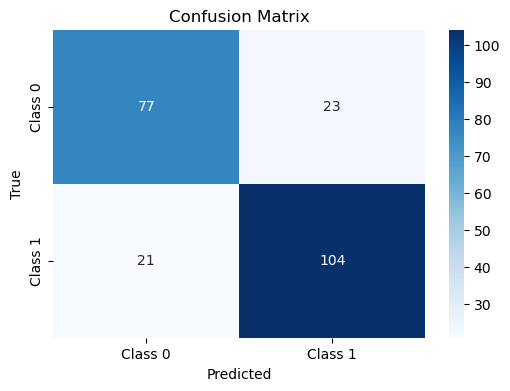

In [147]:
# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [148]:
# Step 4: Separate features (X) and target (y)
X = final_df.drop(columns=['target', 'Unnamed: 0', 'Sample_ID_x', 'Sample_ID_y'])  # Features
y = final_df['target']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=142)
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [154]:
# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=142, max_depth=None,n_estimators=100, class_weight="balanced")

# Fit the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]  # For ROC/AUC

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC AUC Score: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       100
           1       0.81      0.84      0.82       125

    accuracy                           0.80       225
   macro avg       0.80      0.79      0.80       225
weighted avg       0.80      0.80      0.80       225


Confusion Matrix:
[[ 75  25]
 [ 20 105]]

ROC AUC Score: 0.8746


/Users/solozobovavaleria/anaconda3/lib/python3.11/site-packages/xgboost/core.py:160: UserWarning: [11:31:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
